실습 목표<br>
1. 특성 2개가 어떤 식으로 예측하는지 이해 한다.<br>
  -> 수식: y = a1x1 + a2x2 + b<br>
2. 경사하강법( GD )으로 기울기 ( 가중치 ) a1, a2와 절편 b를 직접 업데이트 해 본다<br>
  -> 오차( MSE )를 줄이는 방향으로 파라미터를 반복 수정 -> 손실함수<br>
3. 기울기( 미분값 )이 왜 업데이트 방향을 알려주는지 설명할 수 있다<br>
  -> 오차가 큰 방향을 미분이 알려주고 그 반대 방향으로 이동
---

```txt
앞서 학생들이 공부한 시간에 따른 예측 직선을 그리고자 기울기 a와 y 절편 b를 구했습니다. 
그런데 이 예측 직선을 이용해도 실제 성적 사이에는 약간의 오차가 있었습니다. 
4시간 공부한 친구는 88점을 예측했는데 이보다 좋은 93점을 받았고, 
6시간 공부한 친구는 93점을 받을 것으로 예측했지만 91점을 받았습니다. 
이러한 차이가 생기는 이유는 공부한 시간 이외의 다른 요소가 성적에 영향을 끼쳤기 때문입니다.

더 정확한 예측을 하려면 추가 정보를 입력해야 하며, 정보를 추가해 새로운 예측 값을
구하려면 변수 개수를 늘려 다중 선형 회귀를 만들어 주어야 합니다.

예를 들어 일주일 동안 받는 과외 수업 횟수를 조사해서 이를 기록해 보았습니다.

```
**표 5-1** | 공부한 시간, 과외 수업 횟수에 따른 성적 데이터

| 공부한 시간(x₁) | 과외 수업 횟수(x₂) | 성적(y) |
|-----------------|---------------------|---------|
| 2               | 0                   | 81      |
| 4               | 4                   | 93      |
| 6               | 2                   | 91      |
| 8               | 3                   | 97      |

```txt
그럼 지금부터 독립 변수가 x1과 x2, 이렇게 두 개 생긴 것입니다. 
이를 사용해 종속 변수 y를 만들 경우 기울기를 두 개 구해야 하므로 다음과 같은 식이 나옵니다.

**식 5-1** | 다중 선형 회귀 식
**y = a₁x₁ + a₂x₂ + b**

a₁ : 공부한 시간에 따른 기울기
a₂ : 과외 수업 횟수에 따른 기울기
b : y 절편
```

---

In [18]:
import numpy as np
import matplotlib.pyplot as plt

공부시간 x1, 과외시간 x2, 성적 y의 넘파일 배열을 생성하기

In [19]:
x1 = np.array([2, 4, 6, 8])
x2 = np.array([0, 4, 2, 3])
y = np.array([81, 93, 91, 97])

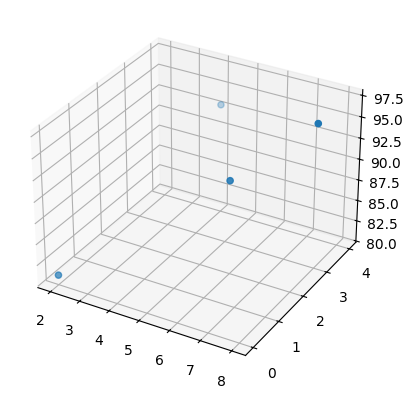

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(x1, x2, y)
plt.show()

In [21]:
# 기울기 a의 값 2개, 절편 b의 값 초기화
a1 = 0
a2 = 0
b = 0

In [22]:
#  학습률을 정하기
lr = 0.01
# 몇 번 반복할지 설정
epochs = 2000

In [23]:
# x값이 총 몇개인지 센다
n = len(x1)
n

4

In [24]:
# 경사 하강법을 시작합니다.
for i in range(epochs):             # 에포크 수만큼 반복합니다. 
    y_pred = a1 * x1 + a2 * x2 + b  # 예측 값을 구하는 식을 세웁니다.
    error = y - y_pred              # 실제 값과 비교한 오차를 error로 놓습니다.

    a1_diff = (2/n) * sum(-x1 * (error))  # 오차 함수를 a1로 편미분한 값입니다. 
    a2_diff = (2/n) * sum(-x2 * (error))  # 오차 함수를 a2로 편미분한 값입니다. 
    b_diff = (2/n) * sum(-(error))        # 오차 함수를 b로 편미분한 값입니다. 

    a1 = a1 - lr * a1_diff      # 학습률을 곱해 기존의 a1 값을 업데이트합니다.
    a2 = a2 - lr * a2_diff      # 학습률을 곱해 기존의 a2 값을 업데이트합니다.
    b = b - lr * b_diff         # 학습률을 곱해 기존의 b 값을 업데이트합니다.

    if i % 100 == 0:   # 100번 반복될 때마다 현재의 a1, a2, b의 값을 출력합니다.
        print("epoch=%.f, 기울기1=%.04f, 기울기2=%.04f, 절편=%.04f" % (i, a1, a2, b))

epoch=0, 기울기1=9.2800, 기울기2=4.2250, 절편=1.8100
epoch=100, 기울기1=9.5110, 기울기2=5.0270, 절편=22.9205
epoch=200, 기울기1=7.3238, 기울기2=4.2950, 절편=37.8751
epoch=300, 기울기1=5.7381, 기울기2=3.7489, 절편=48.7589
epoch=400, 기울기1=4.5844, 기울기2=3.3507, 절편=56.6800
epoch=500, 기울기1=3.7447, 기울기2=3.0608, 절편=62.4448
epoch=600, 기울기1=3.1337, 기울기2=2.8498, 절편=66.6404
epoch=700, 기울기1=2.6890, 기울기2=2.6962, 절편=69.6938
epoch=800, 기울기1=2.3653, 기울기2=2.5845, 절편=71.9160
epoch=900, 기울기1=2.1297, 기울기2=2.5032, 절편=73.5333
epoch=1000, 기울기1=1.9583, 기울기2=2.4440, 절편=74.7103
epoch=1100, 기울기1=1.8336, 기울기2=2.4009, 절편=75.5670
epoch=1200, 기울기1=1.7428, 기울기2=2.3695, 절편=76.1904
epoch=1300, 기울기1=1.6767, 기울기2=2.3467, 절편=76.6441
epoch=1400, 기울기1=1.6286, 기울기2=2.3301, 절편=76.9743
epoch=1500, 기울기1=1.5936, 기울기2=2.3180, 절편=77.2146
epoch=1600, 기울기1=1.5681, 기울기2=2.3092, 절편=77.3895
epoch=1700, 기울기1=1.5496, 기울기2=2.3028, 절편=77.5168
epoch=1800, 기울기1=1.5361, 기울기2=2.2982, 절편=77.6095
epoch=1900, 기울기1=1.5263, 기울기2=2.2948, 절편=77.6769


In [25]:
# 실제 점수와 예측 점수를 출력해 본다
print('실제 점수: ', y)
print('예측 점수: ', y_pred)

실제 점수:  [81 93 91 97]
예측 점수:  [80.76357962 92.97144864 91.42519805 96.75600726]


In [26]:
# 평균제곱오차( MSE ) 계산
y_pred = y_pred = a1 * x1 + a2 * x2 + b
# MSE공식
# 왜 평균을 구하나? -> 데이터 개수 영향 제거
mse = np.mean(y - y_pred)**2
print('평균제곱오차( MSE )', mse ) # 왜 이렇게 잘 맞음 -> 값이 적을 수록 잘 맞음

평균제곱오차( MSE ) 0.00043577271302277295


In [27]:
error = y - y_pred
error

array([ 0.23612355,  0.02846078, -0.42520875,  0.2441251 ])

In [28]:
# 오차 제곱
squared_error = error ** 2
squared_error

array([0.05575433, 0.00081002, 0.18080248, 0.05959706])

In [29]:
print(np.sum(squared_error)/n)

0.07424097305830339


---

```txt
1. -0.24
2. -0.03
3. +0.43
4. -0.24
오차가 모두 +, -0.5이내 -> 굉장히 정확한 모델
모델 품질 평가
- 선형 모델이 데이터에 매우 잘 맞는다.
- 데이터 갯수가 너무 작다.
- 과적합 여부 판단 어려움( 검증 데이터 필요 )
```